<a href="https://colab.research.google.com/github/MuhammadNihalImran/ML_Lab_Tasks/blob/main/ML_Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load a dataset for classification (Breast Cancer dataset)

In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 2. Apply Data Preprocessing

In [ ]:
nulls = df.isnull().sum()
print(nulls[nulls > 0])

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [ ]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [ ]:
df = df.drop('deck', axis=1)

In [ ]:
nulls = df.isnull().sum()
print(nulls[nulls > 0])

Series([], dtype: int64)


In [ ]:
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked', 'class', 'who'],
    drop_first=True
)

In [ ]:
df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,0,3,22.0,1,0,7.2500,True,Southampton,no,False,True,False,True,False,True,True,False
1,1,1,38.0,1,0,71.2833,False,Cherbourg,yes,False,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,Southampton,yes,True,False,False,True,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,Southampton,yes,False,False,False,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,Southampton,no,True,True,False,True,False,True,True,False


### 3. Split the dataset into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (455, 30)
Testing set shape: (114, 30)


### 4. Train a Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf_classifier.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0])

### 5. Make predictions and 6. Evaluate performance (Random Forest)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = rf_classifier.predict(X_test)

print("Evaluating Random Forest performance...")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"Random Forest Precision: {precision_rf:.2f}")
print(f"Random Forest Recall: {recall_rf:.2f}")
print(f"Random Forest F1-Score: {f1_rf:.2f}")

Evaluating Random Forest performance...
Random Forest Accuracy: 0.96
Random Forest Precision: 0.96
Random Forest Recall: 0.97
Random Forest F1-Score: 0.97


### 7. Visualize the Confusion Matrix (Random Forest)

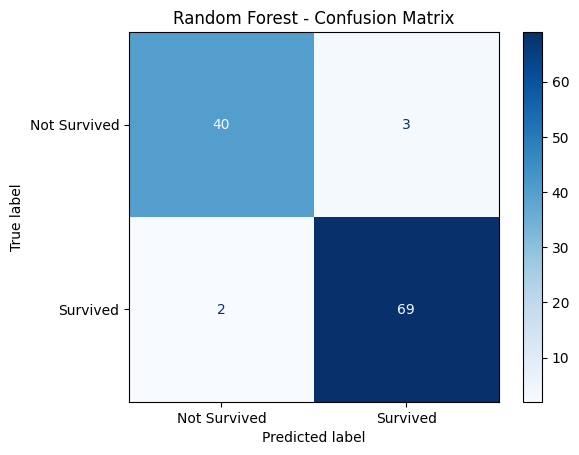

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay( confusion_matrix=cm,
    display_labels=['Not Survived', 'Survived']
)
disp.plot(cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.show()

### 8. Compare with a Single Decision Tree

DecisionTreeClassifier()

### Make predictions and Evaluate performance (Decision Tree)

In [ ]:
print("Making predictions with Decision Tree...")
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

print("Evaluating Decision Tree performance...")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

Making predictions with Decision Tree...
Evaluating Decision Tree performance...


### Comparison Summary

In [ ]:
print("\nComparison Summary:")
print("-------------------")
print(f"Random Forest Accuracy: {accuracy_rf:.4f} vs Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f} vs Decision Tree Precision: {precision_dt:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f} vs Decision Tree Recall: {recall_dt:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f} vs Decision Tree F1-Score: {f1_dt:.4f}")


Comparison Summary:
-------------------
Random Forest Accuracy: 0.9561 vs Decision Tree Accuracy: 0.9386
Random Forest Precision: 0.9583 vs Decision Tree Precision: 0.9444
Random Forest Recall: 0.9718 vs Decision Tree Recall: 0.9577
Random Forest F1-Score: 0.9650 vs Decision Tree F1-Score: 0.9510
